In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## playing around

In [ ]:
hdf_path = '/gscratch/stf/roboviz/expert_lampshade2_demos.hdf5'
with h5py.File(hdf_path, 'r') as hdf:
    demo_group = hdf['data']['demo_0']
    obs_group = demo_group['obs']
    print("Keys under 'obs':", list(obs_group.keys()))
    trajectory_data = obs_group['states'][:]
    print("Trajectory data shape:", trajectory_data.shape)
    print("Sample data:", trajectory_data[:5])

Keys under 'obs': ['front_image', 'states', 'wrist_image']
Trajectory data shape: (114, 8)
Sample data: [[ 3.07179268e-01  2.10159156e-04  5.89663556e-01 -5.11044591e-06
   9.99999995e-01  5.77529119e-05 -8.21542230e-05  1.00000000e+00]
 [ 3.07178382e-01  2.06763012e-04  5.89665456e-01 -4.65351437e-06
   9.99999995e-01  5.41132124e-05 -7.95150517e-05  1.00000000e+00]
 [ 3.07178252e-01  2.08723990e-04  5.89665461e-01 -2.91582916e-06
   9.99999995e-01  5.67510647e-05 -7.79190208e-05  1.00000000e+00]
 [ 3.07178924e-01  2.06177432e-04  5.89664804e-01 -7.58332253e-06
   9.99999995e-01  5.45657094e-05 -7.77385295e-05  1.00000000e+00]
 [ 3.09100198e-01 -1.22322468e-03  5.87578827e-01 -5.62983050e-04
   9.99998584e-01 -1.39743900e-03 -7.49825071e-04  1.00000000e+00]]


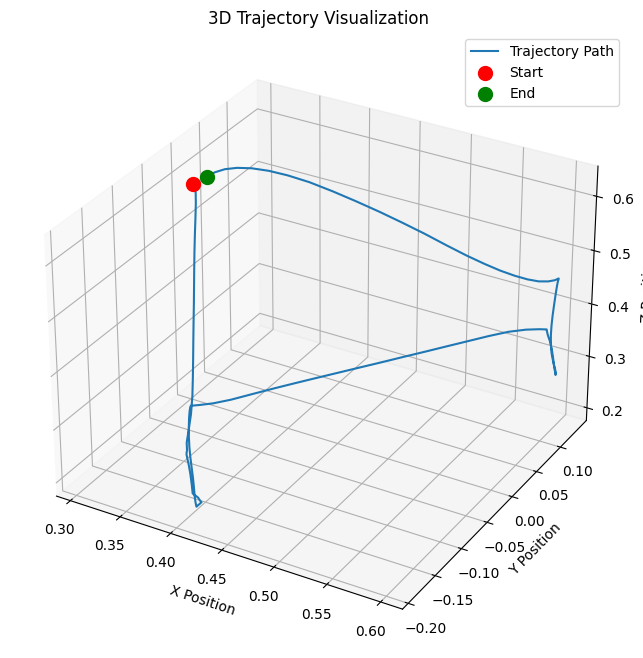

In [ ]:
x = trajectory_data[:, 0]
y = trajectory_data[:, 1]
z = trajectory_data[:, 2]
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x, y, z, label='Trajectory Path')
ax.scatter(x[0], y[0], z[0], color='red', label='Start', s=100)  
ax.scatter(x[-1], y[-1], z[-1], color='green', label='End', s=100)  

ax.set_title('3D Trajectory Visualization')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Z Position')
ax.legend()
plt.show()

## Analyzing the trajectories 

Target resample length (median): 114
HDBSCAN cluster labels: [-1  0  1  2] ( -1 indicates outliers )
Cluster 0 entropy: -4977.2983
Cluster 1 entropy: -4979.0319
Cluster 2 entropy: -4956.6230
Cluster sizes: {0: 6, 1: 7, 2: 43}
Cluster 0 score: 533.2820
Cluster 1 score: 622.3790
Cluster 2 score: 3805.9783
Dynamically identified expert clusters: [1, 2]
Expert Cluster 1 hotspots:
 [[ 3.95478139e-01 -1.70511088e-01  3.02840462e-01 -9.04989866e-04
   9.99967241e-01 -1.18320036e-04 -2.12830480e-03  1.00000000e+00]
 [ 5.87724489e-01  1.13393951e-01  3.62329376e-01  1.40501130e-04
   9.99964470e-01  2.88105076e-03 -2.62444481e-03  1.00000000e+00]
 [ 3.21977129e-01 -2.21520610e-02  5.58990007e-01  3.13301626e-04
   9.99968482e-01  1.01422554e-03  7.50369226e-03  1.00000000e+00]
 [ 4.86445599e-01 -3.74346196e-02  3.80039082e-01 -6.10107858e-04
   9.99955255e-01 -6.47527413e-04 -9.14688287e-03  1.00000000e+00]]

Expert Cluster 2 hotspots:
 [[ 4.10274046e-01 -1.71234029e-01  3.03883184e-01 -1.08298

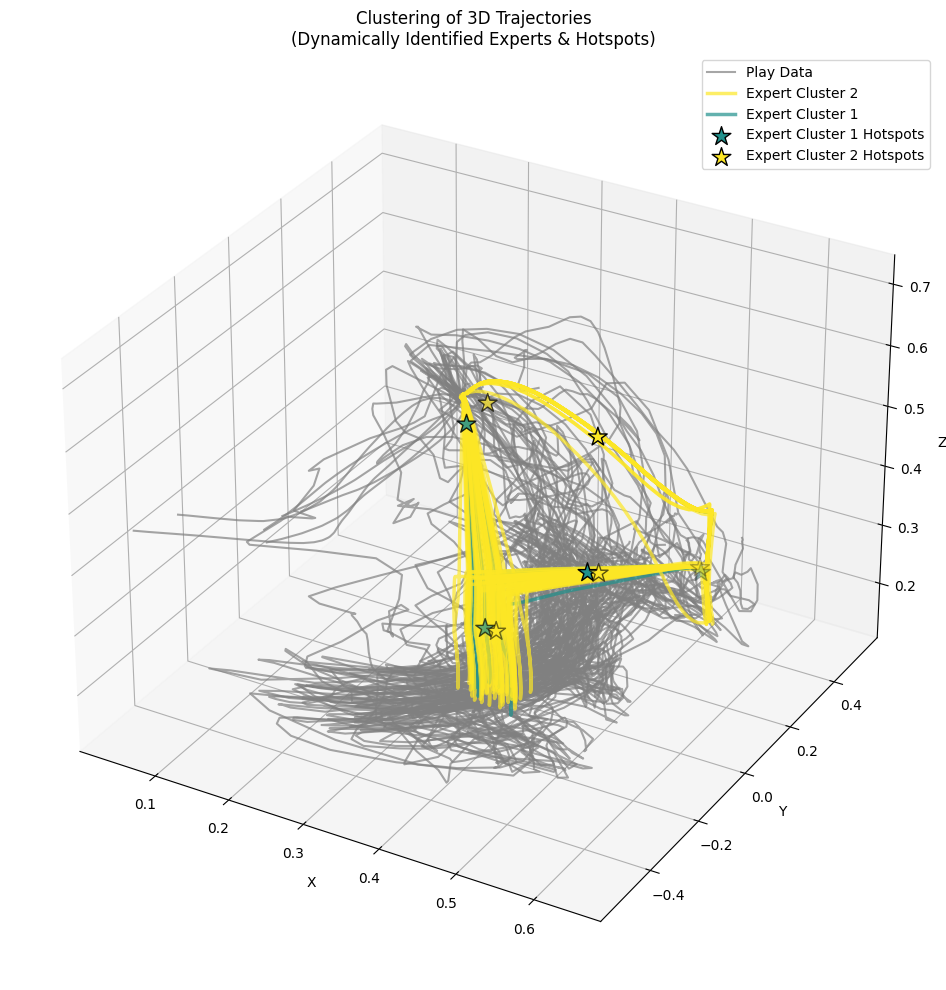

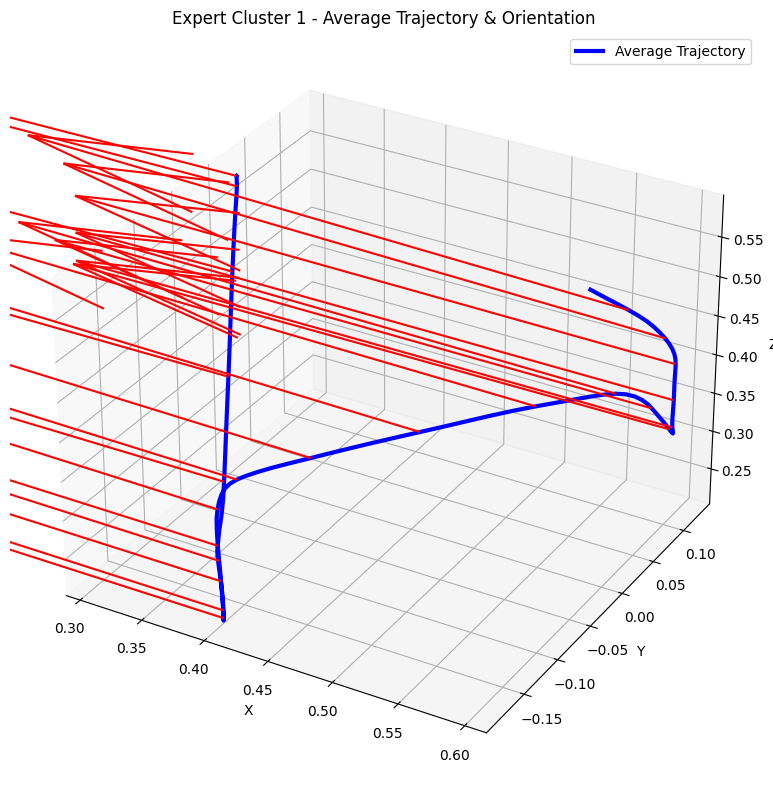

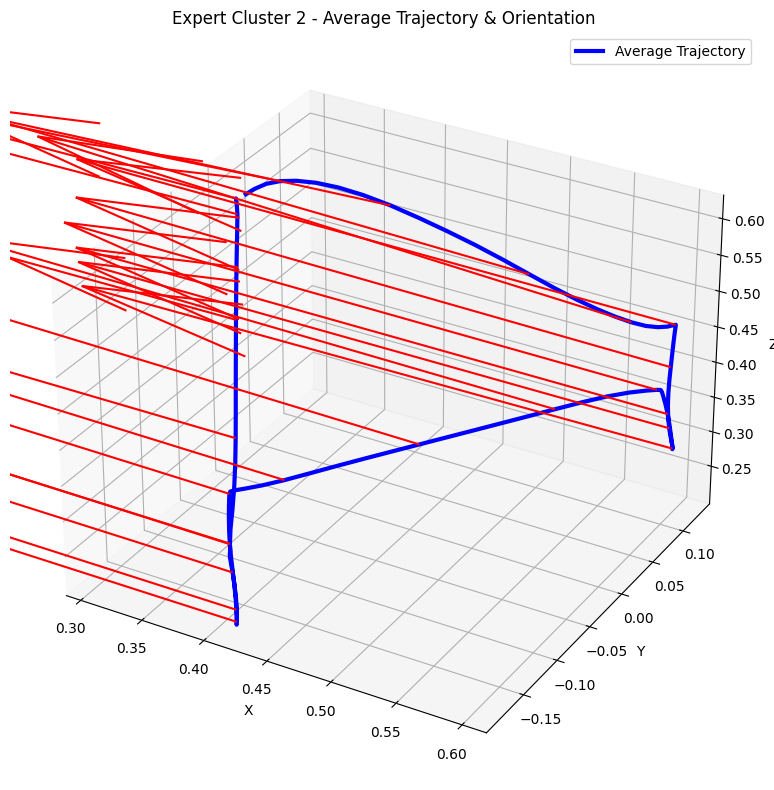

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting
import hdbscan
from sklearn.cluster import MeanShift, estimate_bandwidth
from scipy.spatial.transform import Rotation as R  # For quaternion operations

# =============================================================================
# 1. Load full trajectories from an HDF5 file
# =============================================================================
def load_trajectories(file_path):
    """
    Loads complete trajectories from the given HDF5 file.
    Each demonstration (demo) is assumed to have an 'obs/states' dataset.
    
    Returns:
        A list of np.arrays, each of shape (n_steps, state_dim).
    """
    trajectories = []
    with h5py.File(file_path, 'r') as hdf:
        data_group = hdf['data']
        for demo_key in data_group:
            demo_group = data_group[demo_key]
            if 'obs' in demo_group and 'states' in demo_group['obs']:
                traj = demo_group['obs']['states'][:]
                if traj.shape[0] > 0:
                    trajectories.append(traj)
    return trajectories

# =============================================================================
# 2. Dynamically choose a target resample length based on the data
# =============================================================================
def choose_resample_length(trajectories):
    """
    Chooses a target length to which all trajectories will be resampled.
    Here we use the median length of all trajectories.
    
    Args:
        trajectories (list of np.array): List of trajectories.
        
    Returns:
        target_length (int): The chosen target length.
    """
    lengths = [traj.shape[0] for traj in trajectories]
    return int(np.median(lengths))

# =============================================================================
# 3. Resample a trajectory to a fixed length (using linear interpolation)
# =============================================================================
def resample_trajectory(traj, new_length):
    """
    Resamples a trajectory (shape: (original_length, state_dim))
    to have exactly 'new_length' timesteps via linear interpolation.
    
    Args:
        traj (np.array): Original trajectory.
        new_length (int): Desired number of timesteps.
    
    Returns:
        new_traj (np.array): Resampled trajectory of shape (new_length, state_dim).
    """
    original_length = traj.shape[0]
    state_dim = traj.shape[1]
    old_indices = np.arange(original_length)
    new_indices = np.linspace(0, original_length - 1, new_length)
    new_traj = np.zeros((new_length, state_dim))
    for d in range(state_dim):
        new_traj[:, d] = np.interp(new_indices, old_indices, traj[:, d])
    return new_traj

# =============================================================================
# 4. Feature extraction for a single trajectory (using the entire trajectory)
# =============================================================================
def extract_features(traj):
    """
    Flattens the entire trajectory (assumed shape: (n_steps, state_dim))
    into a single 1D feature vector.
    
    Note: All trajectories must be the same length.
    """
    return traj.flatten()

# =============================================================================
# 5. Compute the differential entropy for a set of features
# =============================================================================
def compute_cluster_entropy(cluster_features):
    """
    Computes a simple differential entropy for the given features assuming a 
    multivariate Gaussian distribution. A lower entropy suggests that the 
    features are more tightly clustered.
    
    Args:
        cluster_features (np.array): Array of shape (n_samples, feature_dim)
    
    Returns:
        entropy (float): The computed entropy.
    """
    cov = np.cov(cluster_features, rowvar=False)
    d = cluster_features.shape[1]
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        cov += np.eye(d) * 1e-6
        sign, logdet = np.linalg.slogdet(cov)
    entropy = 0.5 * (d * np.log(2 * np.pi * np.e) + logdet)
    return entropy

# =============================================================================
# 6. Extract hotspots from a set of points using MeanShift (kernel density)
# =============================================================================
def extract_hotspots(points, quantile=0.2):
    """
    Given an array of points (n_points, d), uses MeanShift clustering 
    (which employs kernel density estimation) to identify hotspots.
    
    Args:
        points (np.array): Array of shape (n_points, d) representing positions.
        quantile (float): Parameter to estimate the bandwidth.
        
    Returns:
        hotspots (np.array): Cluster centers representing hotspots.
    """
    if points.shape[0] == 0:
        return np.empty((0, points.shape[1]))
    bandwidth = estimate_bandwidth(points, quantile=quantile, n_samples=len(points))
    ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    ms.fit(points)
    return ms.cluster_centers_

# =============================================================================
# 7. Main: Clustering, expert cluster identification, hotspot extraction,
#    overall plotting, and per-expert-cluster average trajectory/orientation plots.
# =============================================================================

# Custom file paths for play and expert data:
hdf_path_play   = '/gscratch/stf/roboviz/play_pushing.hdf5'
hdf_path_expert = '/gscratch/stf/roboviz/expert_lampshade2_demos.hdf5'
trajectories1 = load_trajectories(hdf_path_play)
trajectories2 = load_trajectories(hdf_path_expert)
trajectories = trajectories1 + trajectories2

def main():
    # -- Trajectory processing --
    target_length = choose_resample_length(trajectories)
    print("Target resample length (median):", target_length)
    
    all_traj_resampled = [resample_trajectory(traj, new_length=target_length)
                          for traj in trajectories]
    
    features = np.array([extract_features(traj) for traj in all_traj_resampled])
    
    # -- Clustering --
    clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=2)
    cluster_labels = clusterer.fit_predict(features)
    unique_labels = np.unique(cluster_labels)
    print("HDBSCAN cluster labels:", unique_labels, "( -1 indicates outliers )")
    
    # -- Compute entropy and sizes for valid clusters --
    cluster_entropies = {}
    valid_labels = [lbl for lbl in unique_labels if lbl != -1]
    for lbl in valid_labels:
        cluster_features = features[cluster_labels == lbl]
        entropy = compute_cluster_entropy(cluster_features)
        cluster_entropies[lbl] = entropy
        print(f"Cluster {lbl} entropy: {entropy:.4f}")
    
    cluster_sizes = {lbl: np.sum(cluster_labels == lbl) for lbl in valid_labels}
    print("Cluster sizes:", cluster_sizes)
    
    total_valid = sum(cluster_sizes[lbl] for lbl in valid_labels)
    cluster_scores = {lbl: (-cluster_entropies[lbl]) * (cluster_sizes[lbl] / total_valid)
                      for lbl in valid_labels}
    for lbl in valid_labels:
        print(f"Cluster {lbl} score: {cluster_scores[lbl]:.4f}")
    
    scores_array = np.array(list(cluster_scores.values()))
    dynamic_threshold = np.median(scores_array)
    expert_clusters = [lbl for lbl, score in cluster_scores.items() if score >= dynamic_threshold]
    print("Dynamically identified expert clusters:", expert_clusters)
    
    # -- Compute hotspots only for expert clusters (using MeanShift) --
    expert_hotspots = {}
    for lbl in expert_clusters:
        cluster_points = np.vstack([traj for traj, cl in zip(all_traj_resampled, cluster_labels) if cl == lbl])
        hotspots = extract_hotspots(cluster_points, quantile=0.2)
        expert_hotspots[lbl] = hotspots
        print(f"Expert Cluster {lbl} hotspots:\n {hotspots}\n")
    
    # -- Overall 3D plot: trajectories and hotspots --
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # For expert clusters, use a colormap and mapping:
    n_clusters = len(valid_labels)
    cmap = plt.get_cmap('viridis', n_clusters if n_clusters > 0 else 1)
    label_to_color_idx = {lbl: i for i, lbl in enumerate(valid_labels)}
    
    # Use a dictionary to ensure legend labels are added only once.
    legend_labels = {"Play Data": False}
    for expert in expert_clusters:
        legend_labels[f"Expert Cluster {expert}"] = False

    # Plot each trajectory
    for traj, lbl in zip(all_traj_resampled, cluster_labels):
        if lbl in expert_clusters:
            # Expert cluster: unique color and thicker line.
            color_idx = label_to_color_idx[lbl]
            color = cmap(color_idx)
            lw = 2.5
            label_str = f"Expert Cluster {lbl}"
        else:
            # Non-expert (play data)
            color = "gray"
            lw = 1.5
            label_str = "Play Data"
    
        if not legend_labels[label_str]:
            ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], color=color, alpha=0.7, lw=lw, label=label_str)
            legend_labels[label_str] = True
        else:
            ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], color=color, alpha=0.7, lw=lw)
    
    # Plot hotspots only for expert clusters
    for lbl in expert_clusters:
        hotspots = expert_hotspots[lbl]
        if hotspots.size > 0:
            color_idx = label_to_color_idx[lbl]
            color = cmap(color_idx)
            ax.scatter(hotspots[:, 0], hotspots[:, 1], hotspots[:, 2],
                       s=200, marker='*', color=color, edgecolor='k',
                       label=f'Expert Cluster {lbl} Hotspots')
    
    ax.set_title("Clustering of 3D Trajectories\n(Dynamically Identified Experts & Hotspots)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()
    
    # -- For each expert cluster: compute and plot average trajectory with orientation --
    # We assume that the state is at least 7 dimensions:
    #   - Columns 0-2: 3D position.
    #   - Columns 3-6: Quaternion (stored as [qx, qy, qz, qw]).
    # For each time step, we average the quaternions (using SciPy's Rotation.mean)
    # and then convert the average quaternion to a direction vector by applying it
    # to a reference vector ([1, 0, 0]).
    
    state_dim = all_traj_resampled[0].shape[1]
    for lbl in expert_clusters:
        # Gather trajectories in expert cluster lbl
        cluster_trajs = [traj for traj, cl in zip(all_traj_resampled, cluster_labels) if cl == lbl]
        if len(cluster_trajs) == 0:
            continue
        # Stack trajectories: shape (n_trajs, T, state_dim)
        cluster_array = np.stack(cluster_trajs, axis=0)
        avg_traj = np.mean(cluster_array, axis=0)  # shape: (T, state_dim)
        
        # Compute average orientation if quaternions are available.
        if state_dim >= 7:
            T = avg_traj.shape[0]
            avg_dir = np.zeros((T, 3))
            for i in range(T):
                # Extract quaternions from columns 3-6
                quats = cluster_array[:, i, 3:7]  # shape: (n_trajs, 4)
                rotations = R.from_quat(quats)
                avg_rot = rotations.mean()
                avg_dir[i] = avg_rot.apply([1, 0, 0])
        else:
            avg_dir = None
        
        fig2 = plt.figure(figsize=(10, 8))
        ax2 = fig2.add_subplot(111, projection='3d')
        
        ax2.plot(avg_traj[:, 0], avg_traj[:, 1], avg_traj[:, 2], 'b-', lw=3, label='Average Trajectory')
        
        if avg_dir is not None:
            T = avg_traj.shape[0]
            step = max(1, T // 20)
            for i in range(0, T, step):
                x, y, z = avg_traj[i, 0], avg_traj[i, 1], avg_traj[i, 2]
                dx, dy, dz = avg_dir[i]
                arrow_length = 0.5
                ax2.quiver(x, y, z, dx, dy, dz, length=arrow_length, normalize=True, color='r')
        
        ax2.set_title(f"Expert Cluster {lbl} - Average Trajectory & Orientation")
        ax2.set_xlabel("X")
        ax2.set_ylabel("Y")
        ax2.set_zlabel("Z")
        ax2.legend(loc='best')
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()

# Animation

In [2]:
%matplotlib widget

Target resample length (median): 114
HDBSCAN cluster labels: [-1  0  1  2] ( -1 indicates outliers )
Cluster 0 entropy: -4977.2983
Cluster 1 entropy: -4979.0319
Cluster 2 entropy: -4956.6230
Cluster sizes: {0: 6, 1: 7, 2: 43}
Cluster 0 score: 533.2820
Cluster 1 score: 622.3790
Cluster 2 score: 3805.9783
Dynamically identified expert clusters: [1, 2]
Expert Cluster 1 hotspots:
 [[ 3.95478139e-01 -1.70511088e-01  3.02840462e-01 -9.04989866e-04
   9.99967241e-01 -1.18320036e-04 -2.12830480e-03  1.00000000e+00]
 [ 5.87724489e-01  1.13393951e-01  3.62329376e-01  1.40501130e-04
   9.99964470e-01  2.88105076e-03 -2.62444481e-03  1.00000000e+00]
 [ 3.21977129e-01 -2.21520610e-02  5.58990007e-01  3.13301626e-04
   9.99968482e-01  1.01422554e-03  7.50369226e-03  1.00000000e+00]
 [ 4.86445599e-01 -3.74346196e-02  3.80039082e-01 -6.10107858e-04
   9.99955255e-01 -6.47527413e-04 -9.14688287e-03  1.00000000e+00]]

Expert Cluster 2 hotspots:
 [[ 4.10274046e-01 -1.71234029e-01  3.03883184e-01 -1.08298

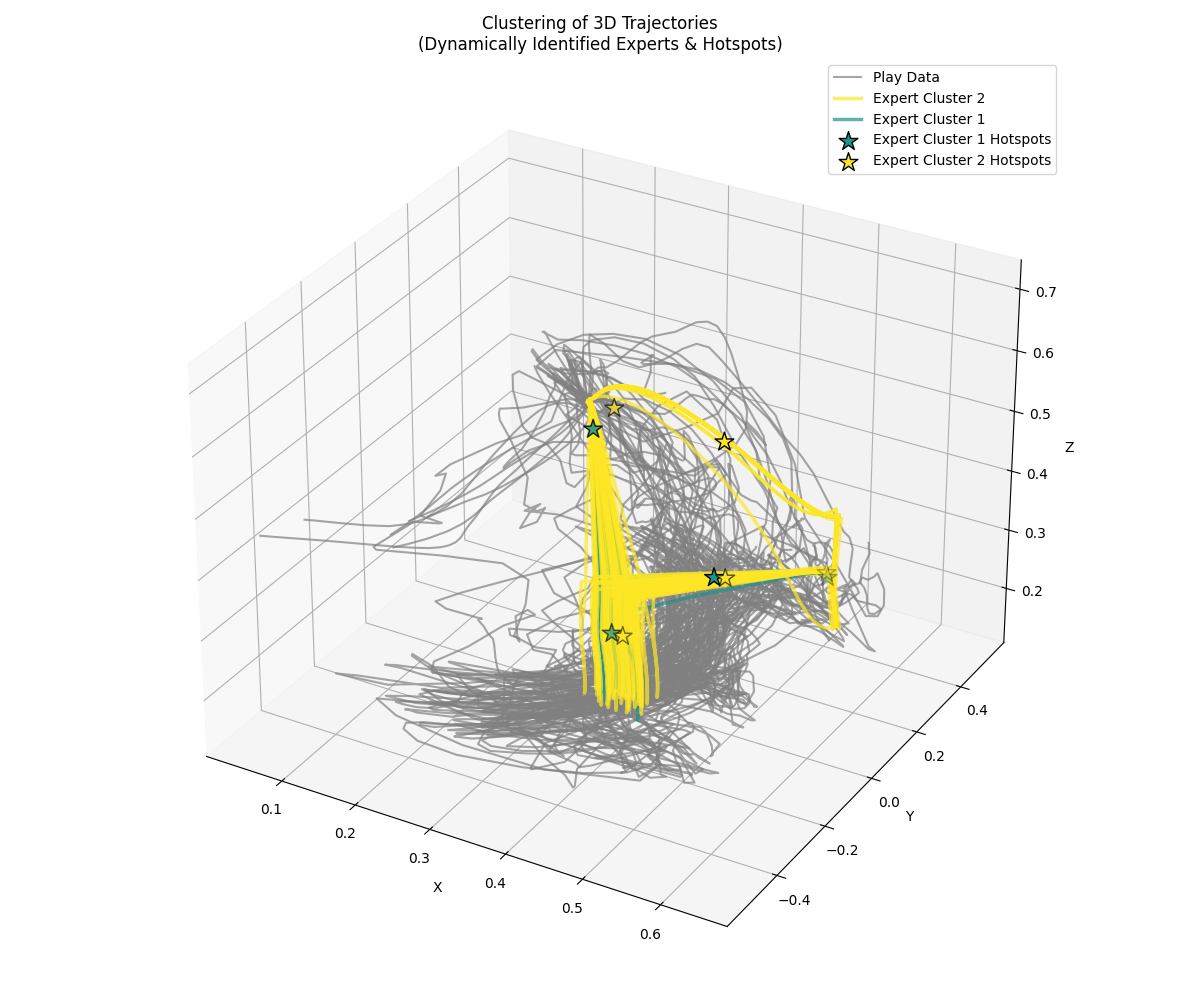

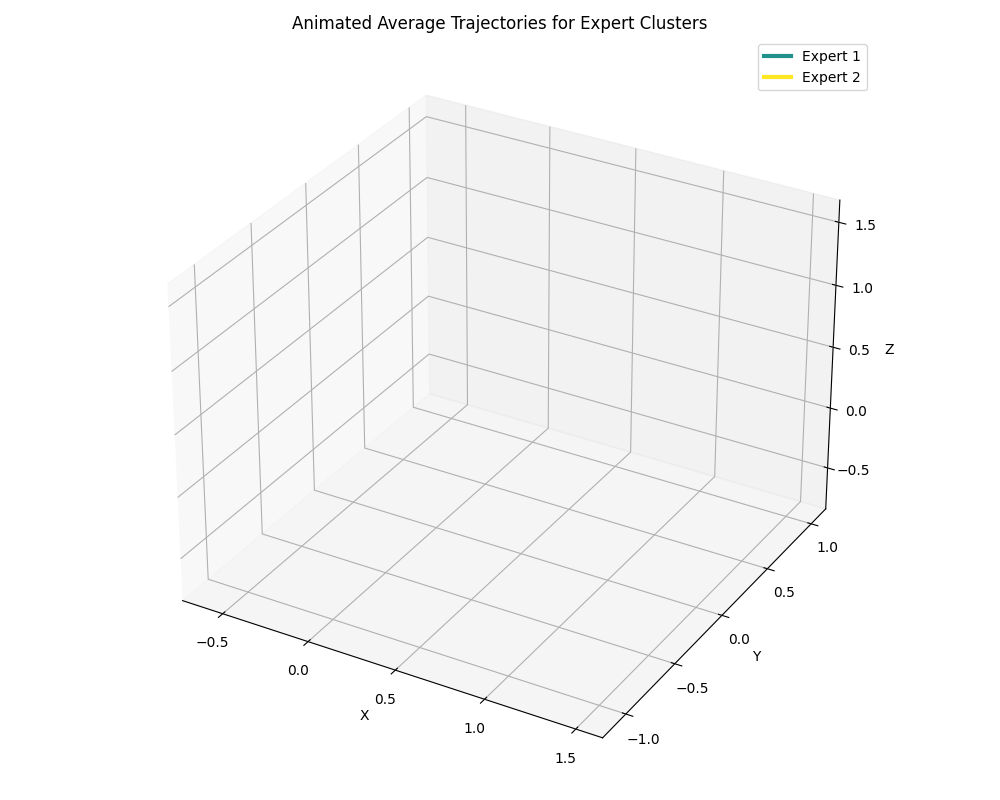

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting
import hdbscan
from sklearn.cluster import MeanShift, estimate_bandwidth
from scipy.spatial.transform import Rotation as R  # For quaternion operations
import matplotlib.animation as animation

# Global list to hold animation objects so they are not garbage-collected.
global_animations = []

# =============================================================================
# 1. Load full trajectories from an HDF5 file
# =============================================================================
def load_trajectories(file_path):
    trajectories = []
    with h5py.File(file_path, 'r') as hdf:
        data_group = hdf['data']
        for demo_key in data_group:
            demo_group = data_group[demo_key]
            if 'obs' in demo_group and 'states' in demo_group['obs']:
                traj = demo_group['obs']['states'][:]
                if traj.shape[0] > 0:
                    trajectories.append(traj)
    return trajectories

# =============================================================================
# 2. Dynamically choose a target resample length based on the data
# =============================================================================
def choose_resample_length(trajectories):
    lengths = [traj.shape[0] for traj in trajectories]
    return int(np.median(lengths))

# =============================================================================
# 3. Resample a trajectory to a fixed length (using linear interpolation)
# =============================================================================
def resample_trajectory(traj, new_length): 
    original_length = traj.shape[0]
    state_dim = traj.shape[1]
    old_indices = np.arange(original_length)
    new_indices = np.linspace(0, original_length - 1, new_length)
    new_traj = np.zeros((new_length, state_dim))
    for d in range(state_dim):
        new_traj[:, d] = np.interp(new_indices, old_indices, traj[:, d])
    return new_traj

# =============================================================================
# 4. Feature extraction for a single trajectory (using the entire trajectory)
# =============================================================================
def extract_features(traj):
    return traj.flatten()

# =============================================================================
# 5. Compute the differential entropy for a set of features
# =============================================================================
def compute_cluster_entropy(cluster_features):
    cov = np.cov(cluster_features, rowvar=False)
    d = cluster_features.shape[1]
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        cov += np.eye(d) * 1e-6
        sign, logdet = np.linalg.slogdet(cov)
    entropy = 0.5 * (d * np.log(2 * np.pi * np.e) + logdet)
    return entropy

# =============================================================================
# 6. Extract hotspots from a set of points using MeanShift (kernel density)
# =============================================================================
def extract_hotspots(points, quantile=0.2):
    if points.shape[0] == 0:
        return np.empty((0, points.shape[1]))
    bandwidth = estimate_bandwidth(points, quantile=quantile, n_samples=len(points))
    ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    ms.fit(points)
    return ms.cluster_centers_

# =============================================================================
# 7. Main: Clustering, plotting, and simultaneous animation of expert averages.
# =============================================================================

# Custom file paths (adjust these to your actual data locations):
hdf_path_play   = '/gscratch/stf/roboviz/play_pushing.hdf5'
hdf_path_expert = '/gscratch/stf/roboviz/expert_lampshade2_demos.hdf5'
trajectories1 = load_trajectories(hdf_path_play)
trajectories2 = load_trajectories(hdf_path_expert)
trajectories = trajectories1 + trajectories2

def main():
    global global_animations  # to keep animation objects alive
    
    # -- Trajectory processing --
    target_length = choose_resample_length(trajectories)
    print("Target resample length (median):", target_length)
    
    all_traj_resampled = [resample_trajectory(traj, new_length=target_length)
                          for traj in trajectories]
    features = np.array([extract_features(traj) for traj in all_traj_resampled])
    
    # -- Clustering --
    clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=2)
    cluster_labels = clusterer.fit_predict(features)
    unique_labels = np.unique(cluster_labels)
    print("HDBSCAN cluster labels:", unique_labels, "( -1 indicates outliers )")
    
    # -- Compute entropy and sizes for valid clusters --
    cluster_entropies = {}
    valid_labels = [lbl for lbl in unique_labels if lbl != -1]
    for lbl in valid_labels:
        cluster_features = features[cluster_labels == lbl]
        entropy = compute_cluster_entropy(cluster_features)
        cluster_entropies[lbl] = entropy
        print(f"Cluster {lbl} entropy: {entropy:.4f}")
    
    cluster_sizes = {lbl: np.sum(cluster_labels == lbl) for lbl in valid_labels}
    print("Cluster sizes:", cluster_sizes)
    
    total_valid = sum(cluster_sizes[lbl] for lbl in valid_labels)
    cluster_scores = {lbl: (-cluster_entropies[lbl]) * (cluster_sizes[lbl] / total_valid)
                      for lbl in valid_labels}
    for lbl in valid_labels:
        print(f"Cluster {lbl} score: {cluster_scores[lbl]:.4f}")
    
    scores_array = np.array(list(cluster_scores.values()))
    dynamic_threshold = np.median(scores_array)
    expert_clusters = [lbl for lbl, score in cluster_scores.items() if score >= dynamic_threshold]
    print("Dynamically identified expert clusters:", expert_clusters)
    
    # -- Compute hotspots only for expert clusters (using MeanShift) --
    expert_hotspots = {}
    for lbl in expert_clusters:
        cluster_points = np.vstack([traj for traj, cl in zip(all_traj_resampled, cluster_labels) if cl == lbl])
        hotspots = extract_hotspots(cluster_points, quantile=0.2)
        expert_hotspots[lbl] = hotspots
        print(f"Expert Cluster {lbl} hotspots:\n {hotspots}\n")
    
    # -- Overall Static 3D Plot: trajectories and hotspots --
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    n_clusters = len(valid_labels)
    cmap = plt.get_cmap('viridis', n_clusters if n_clusters > 0 else 1)
    label_to_color_idx = {lbl: i for i, lbl in enumerate(valid_labels)}
    legend_labels = {"Play Data": False}
    for expert in expert_clusters:
        legend_labels[f"Expert Cluster {expert}"] = False

    for traj, lbl in zip(all_traj_resampled, cluster_labels):
        if lbl in expert_clusters:
            color_idx = label_to_color_idx[lbl]
            color = cmap(color_idx)
            lw = 2.5
            label_str = f"Expert Cluster {lbl}"
        else:
            color = "gray"
            lw = 1.5
            label_str = "Play Data"
    
        if not legend_labels[label_str]:
            ax.plot(traj[:, 0], traj[:, 1], traj[:, 2],
                    color=color, alpha=0.7, lw=lw, label=label_str)
            legend_labels[label_str] = True
        else:
            ax.plot(traj[:, 0], traj[:, 1], traj[:, 2],
                    color=color, alpha=0.7, lw=lw)
    
    for lbl in expert_clusters:
        hotspots = expert_hotspots[lbl]
        if hotspots.size > 0:
            color_idx = label_to_color_idx[lbl]
            color = cmap(color_idx)
            ax.scatter(hotspots[:, 0], hotspots[:, 1], hotspots[:, 2],
                       s=200, marker='*', color=color, edgecolor='k',
                       label=f'Expert Cluster {lbl} Hotspots')
    
    ax.set_title("Clustering of 3D Trajectories\n(Dynamically Identified Experts & Hotspots)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()
    
    
    # work in proggress
    # ---------------------------
    # Animated Average Trajectories for ALL Expert Clusters Simultaneously
    # ---------------------------
    # Compute average trajectories and (if available) average orientations for each expert.
    avg_traj_dict = {}
    avg_dir_dict  = {}
    state_dim = all_traj_resampled[0].shape[1]
    T = target_length  # All trajectories have T timesteps
    
    for lbl in expert_clusters:
        cluster_trajs = [traj for traj, cl in zip(all_traj_resampled, cluster_labels) if cl == lbl]
        if len(cluster_trajs) == 0:
            continue
        cluster_array = np.stack(cluster_trajs, axis=0)  # shape: (n_trajs, T, state_dim)
        avg_traj = np.mean(cluster_array, axis=0)  # shape: (T, state_dim)
        avg_traj_dict[lbl] = avg_traj
        
        if state_dim >= 7:
            avg_dir = np.zeros((T, 3))
            for i in range(T):
                quats = cluster_array[:, i, 3:7]  # shape: (n_trajs, 4)
                rotations = R.from_quat(quats)
                avg_rot = rotations.mean()
                avg_dir[i] = avg_rot.apply([1, 0, 0])
            avg_dir_dict[lbl] = avg_dir
        else:
            avg_dir_dict[lbl] = None

    # Create a single 3D animated plot for all expert clusters.
    fig_anim = plt.figure(figsize=(10, 8))
    ax_anim = fig_anim.add_subplot(111, projection='3d')
    ax_anim.set_title("Animated Average Trajectories for Expert Clusters")
    ax_anim.set_xlabel("X")
    ax_anim.set_ylabel("Y")
    ax_anim.set_zlabel("Z")
    
    # Set overall axis limits based on all averages.
    all_x = np.hstack([avg_traj_dict[lbl][:, 0] for lbl in avg_traj_dict])
    all_y = np.hstack([avg_traj_dict[lbl][:, 1] for lbl in avg_traj_dict])
    all_z = np.hstack([avg_traj_dict[lbl][:, 2] for lbl in avg_traj_dict])
    margin = 1
    ax_anim.set_xlim(all_x.min() - margin, all_x.max() + margin)
    ax_anim.set_ylim(all_y.min() - margin, all_y.max() + margin)
    ax_anim.set_zlim(all_z.min() - margin, all_z.max() + margin)
    
    # Create dictionaries to hold animated objects.
    line_dict = {}
    point_dict = {}
    arrow_dict = {}
    color_dict = {}
    for lbl in expert_clusters:
        color_idx = label_to_color_idx[lbl]
        color = cmap(color_idx)
        color_dict[lbl] = color
        line, = ax_anim.plot([], [], [], '-', lw=3, color=color, label=f"Expert {lbl}")
        point, = ax_anim.plot([], [], [], 'o', markersize=5, color=color)
        line_dict[lbl] = line
        point_dict[lbl] = point
        arrow_dict[lbl] = None

    # Update function for the animation.
    def update_all(frame):
        # For each expert cluster, update its line, point, and arrow.
        for lbl in expert_clusters:
            avg_traj = avg_traj_dict[lbl]
            avg_dir = avg_dir_dict[lbl]
            line_dict[lbl].set_data(avg_traj[:frame+1, 0], avg_traj[:frame+1, 1])
            line_dict[lbl].set_3d_properties(avg_traj[:frame+1, 2])
            current_point = avg_traj[frame]
            point_dict[lbl].set_data([current_point[0]], [current_point[1]])
            point_dict[lbl].set_3d_properties([current_point[2]])
            if avg_dir is not None:
                if arrow_dict[lbl] is not None:
                    try:
                        arrow_dict[lbl].remove()
                    except Exception:
                        pass
                dx, dy, dz = avg_dir[frame]
                arrow_length = 0.3
                arrow_dict[lbl] = ax_anim.quiver(current_point[0], current_point[1], current_point[2],
                                                  dx, dy, dz, length=arrow_length,
                                                  normalize=True, color=color_dict[lbl])
        # Since blit is False, we need not return any artists.
    
    animation_interval = 50  # milliseconds
    ani_all = animation.FuncAnimation(fig_anim, update_all, frames=range(T),
                                      interval=animation_interval, blit=False, repeat=True)
    global_animations.append(ani_all)
    
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()